<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 22px;">09. IMD Approach Validation</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Testing whether Approach A or Approach B better reproduces observed regional rainfall variability, using IMD gridded rainfall (1981-2023) as an independent benchmark against the ERA5-derived series already used to select Approach A in notebook 04.</p>
</div>

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import glob
import os

IMD_DIR = '/home/ucfadod@ad.ucl.ac.uk/Documents/Dissertation/data/raw/imd/'
OUTPUT_DIR = '/home/ucfadod@ad.ucl.ac.uk/Documents/Dissertation/outputs/'

YEAR_START = 1981
YEAR_END = 2023
JJAS = [6, 7, 8, 9]

print('Configuration set')

Configuration set


In [2]:
# Load all 43 IMD yearly files
imd_files = sorted(glob.glob(os.path.join(IMD_DIR, 'RF25_*.nc')))
print(f'Found {len(imd_files)} IMD files')
assert len(imd_files) == 43, f'Expected 43 files, found {len(imd_files)}'

ds_imd = xr.open_mfdataset(imd_files, combine='by_coords', chunks={'TIME': 366})

# Standardise dim/coord names to match ERA5 convention used throughout the project
ds_imd = ds_imd.rename({'LATITUDE': 'lat', 'LONGITUDE': 'lon', 'TIME': 'time'})

print(ds_imd)
print(f"\nVariable attrs: {ds_imd['RAINFALL'].attrs}")
print(f"Time range: {ds_imd.time.min().values} to {ds_imd.time.max().values}")

Found 43 IMD files
<xarray.Dataset> Size: 1GB
Dimensions:   (time: 15705, lat: 129, lon: 135)
Coordinates:
  * lon       (lon) float64 1kB 66.5 66.75 67.0 67.25 ... 99.25 99.5 99.75 100.0
  * lat       (lat) float64 1kB 6.5 6.75 7.0 7.25 7.5 ... 37.75 38.0 38.25 38.5
  * time      (time) datetime64[ns] 126kB 1981-01-01 1981-01-02 ... 2023-12-31
Data variables:
    RAINFALL  (time, lat, lon) float32 1GB dask.array<chunksize=(365, 129, 135), meta=np.ndarray>
Attributes:
    history:      FERRET V6.82   20-Feb-26
    Conventions:  CF-1.0

Variable attrs: {'long_name': 'Rainfall', 'units': 'mm', 'history': 'From ind1981_rfp25.grd'}
Time range: 1981-01-01T00:00:00.000000000 to 2023-12-31T00:00:00.000000000


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Part 2: Rebuild Region Masks on IMD's Grid</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Same region definitions and GADM dissolve logic as notebook 04, re-projected onto IMD's own lat/lon grid (different resolution/domain from ERA5).</p>
</div>

In [3]:
import geopandas as gpd
import regionmask

# Identical region definitions to notebook 04 -- do not change these independently
path = "/home/ucfadod@ad.ucl.ac.uk/Documents/Dissertation/data/gadm/gadm41_IND.gpkg"
gdf = gpd.read_file(path, layer="ADM_ADM_1")
gdf_clean = gdf.dissolve(by="NAME_1")

region_states = {
    'Western_Ghats': ['Kerala', 'Karnataka', 'Goa', 'Maharashtra'],
    'Central_India': ['Madhya Pradesh', 'Chhattisgarh', 'Odisha', 'Jharkhand'],
    'Indo_Gangetic_Plain': ['Uttar Pradesh', 'Bihar', 'West Bengal', 'Punjab', 'Haryana'],
    'Northeast': ['Assam', 'Meghalaya', 'Arunachal Pradesh', 'Tripura']
}

state_to_region = {state: region for region, states in region_states.items() for state in states}
gdf_clean['region'] = gdf_clean.index.map(state_to_region)
gdf_regions = gdf_clean[gdf_clean['region'].notna()].dissolve(by='region')

region_names = gdf_regions.index.tolist()
regions_mask_obj = regionmask.Regions(
    gdf_regions.geometry.tolist(),
    names=region_names,
    abbrevs=[r[:3] for r in region_names]
)

print('Region masks built (identical definitions to notebook 04)')
print(f'Regions: {region_names}')

Region masks built (identical definitions to notebook 04)
Regions: ['Central_India', 'Indo_Gangetic_Plain', 'Northeast', 'Western_Ghats']


In [4]:
# Project onto IMD's grid specifically
lat_imd = ds_imd.lat.values
lon_imd = ds_imd.lon.values

frac_overlap_imd = regions_mask_obj.mask_3D_frac_approx(lon_imd, lat_imd)

print('Fractional overlap mask computed on IMD grid')
print(frac_overlap_imd)

# Sanity check: confirm every region actually has grid coverage in the IMD domain
weight_totals = frac_overlap_imd.sum(dim=['lat', 'lon'])
print('\nTotal weighted grid-cell coverage per region:')
print(weight_totals.values)

Fractional overlap mask computed on IMD grid
<xarray.DataArray 'mask' (region: 4, lat: 129, lon: 135)> Size: 557kB
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        

<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Part 3: Compute Approach A IMD Regional Series</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Rx5day computed per grid cell, per year (JJAS only, matching notebook 02's year-boundary-safe method), then fractional-weighted area-averaged across each region. This is the IMD-side counterpart to the Approach A ERA5 series already loaded from notebook 04.</p>
</div>

In [7]:
def compute_jjas_rx5day_per_gridcell(ds, jjas_months, year_start, year_end):
    """
    Compute JJAS Rx5day per grid cell per year, using the same
    groupby-then-rolling method validated in notebook 02 for ERA5.
    Groups by year FIRST so the 5-day rolling window never crosses
    a year boundary (Sept -> June gap from JJAS-only filtering).
    """
    rain = ds['RAINFALL']
    rain_jjas = rain.sel(time=rain.time.dt.month.isin(jjas_months))
    rain_jjas = rain_jjas.sel(time=rain_jjas.time.dt.year.isin(range(year_start, year_end + 1)))

    def _rx5day_one_year(group):
        return group.rolling(time=5, min_periods=5).sum().max(dim='time')

    rx5day = rain_jjas.groupby('time.year').map(_rx5day_one_year)

    rx5day.name = 'rx5day'
    rx5day.attrs['units'] = 'mm'
    rx5day.attrs['long_name'] = 'Annual maximum 5-day JJAS precipitation (IMD)'
    rx5day.attrs['source'] = 'IMD gridded rainfall'

    return rx5day

print('Computing IMD Rx5day per grid cell, per year (JJAS)...')
rx5day_imd_gridcell = compute_jjas_rx5day_per_gridcell(ds_imd, JJAS, YEAR_START, YEAR_END)
rx5day_imd_gridcell = rx5day_imd_gridcell.compute()

print(rx5day_imd_gridcell)
print(f'Years: {rx5day_imd_gridcell.year.values[0]} to {rx5day_imd_gridcell.year.values[-1]}')

Computing IMD Rx5day per grid cell, per year (JJAS)...
<xarray.DataArray 'rx5day' (year: 43, lat: 129, lon: 135)> Size: 3MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

    

In [8]:
# Check a known land point -- Kerala, well within Western Ghats
kerala_val = rx5day_imd_gridcell.sel(lat=10, lon=76, method='nearest')
print(kerala_val)
print(kerala_val.values)

# Also check overall NaN fraction across the whole array
total_cells = rx5day_imd_gridcell.size
nan_cells = int(np.isnan(rx5day_imd_gridcell.values).sum())
print(f'\nTotal NaN: {nan_cells} / {total_cells} ({100*nan_cells/total_cells:.1f}%)')

<xarray.DataArray 'rx5day' (year: 43)> Size: 172B
array([280.33438, 174.79274, 256.0591 , 203.69255, 256.17493, 200.56294,
       310.7101 , 200.31511, 191.95694, 208.75206, 488.08572, 356.81412,
       421.46   , 387.2897 , 261.90152, 243.30469, 440.00745, 247.52753,
       410.346  , 285.9835 , 320.70807, 314.8713 , 217.7549 , 258.01456,
       246.49149, 382.2613 , 328.71692, 248.80678, 258.3902 , 322.96356,
       246.43265, 127.59304, 279.1945 , 284.77167, 240.46974, 218.26283,
       263.3782 , 355.94778, 455.3949 , 349.58292, 217.79155, 312.9808 ,
       372.77548], dtype=float32)
Coordinates:
    lon      float64 8B 76.0
    lat      float64 8B 10.0
  * year     (year) int64 344B 1981 1982 1983 1984 1985 ... 2020 2021 2022 2023
Attributes:
    units:      mm
    long_name:  Annual maximum 5-day JJAS precipitation (IMD)
    source:     IMD gridded rainfall
[280.33438 174.79274 256.0591  203.69255 256.17493 200.56294 310.7101
 200.31511 191.95694 208.75206 488.08572 356.81412 421

In [10]:
for i, region in enumerate(region_names):
    mask_2d = (frac_overlap_imd.isel(region=i) > 0).values  # shape (lat, lon)
    values = rx5day_imd_gridcell.values  # shape (year, lat, lon)

    mask_broadcast = np.broadcast_to(mask_2d, values.shape)
    nan_in_region = int(np.isnan(values[mask_broadcast]).sum())
    total_in_region = int(mask_broadcast.sum())

    print(f'{region}: {nan_in_region} NaN out of {total_in_region} region-year cells '
          f'({100*nan_in_region/total_in_region:.1f}%)')

Central_India: 559 NaN out of 47214 region-year cells (1.2%)
Indo_Gangetic_Plain: 645 NaN out of 39431 region-year cells (1.6%)
Northeast: 688 NaN out of 15050 region-year cells (4.6%)
Western_Ghats: 43 NaN out of 36894 region-year cells (0.1%)


In [11]:
# Approach A: area-average the per-grid-cell Rx5day values across each region
# Mask weight to only where data isn't NaN, computed per year, so boundary
# NaN cells (ocean/border edge, ~1-5% of region area) are excluded from
# BOTH numerator and denominator consistently
valid_mask = rx5day_imd_gridcell.notnull()  # shape (year, lat, lon)
weight_valid = frac_overlap_imd.where(valid_mask)  # NaN where data is missing, per year

weighted_sum = (rx5day_imd_gridcell * frac_overlap_imd).sum(dim=['lat', 'lon'], skipna=True)
weight_total_valid = weight_valid.sum(dim=['lat', 'lon'], skipna=True)

rx5day_imd_approachA = weighted_sum / weight_total_valid

rx5day_imd_approachA.name = 'rx5day'
rx5day_imd_approachA.to_netcdf(OUTPUT_DIR + 'rx5day_imd_approachA_regional.nc')

print('IMD Approach A regional Rx5day:')
print(rx5day_imd_approachA)
print(f'\nMean per region: {rx5day_imd_approachA.mean(dim="year").values}')

IMD Approach A regional Rx5day:
<xarray.DataArray 'rx5day' (year: 43, region: 4)> Size: 1kB
array([[169.55240065, 202.32836972, 256.26458331, 194.91111037],
       [192.22633935, 173.91011705, 289.27318964, 164.76789837],
       [187.15928008, 190.42838032, 233.94982622, 215.80499197],
       [217.94911207, 214.95351256, 274.7111298 , 176.23952446],
       [183.62038763, 193.46502669, 244.89648209, 162.7601911 ],
       [225.8192662 , 208.98744257, 214.30834642, 184.38960195],
       [195.89496346, 205.21487347, 355.30492209, 143.35962   ],
       [193.08735728, 240.45543911, 329.28030842, 208.52560907],
       [168.97148047, 187.8723362 , 255.62814903, 206.09050075],
       [192.11397912, 196.12622148, 222.62759386, 178.71503679],
       [213.72646992, 188.31286451, 242.93517722, 218.62005665],
       [197.74603447, 161.06435564, 216.75894875, 201.41505705],
       [195.14037697, 199.4083223 , 276.62308679, 167.42512046],
       [240.41444265, 163.11543038, 182.65441103, 200.37933885]

<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Part 4: Compute Approach B IMD Regional Series</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Area-average daily rainfall across each region FIRST, then compute JJAS Rx5day from that regional daily time series. Mirrors the Approach B method used for ERA5 in notebook 04.</p>
</div>

In [12]:
rain = ds_imd['RAINFALL']

# Compare NaN pattern on day 1 vs a day partway through vs the last day
mask_day1 = rain.isel(time=0).isnull().values
mask_mid = rain.isel(time=7000).isnull().values
mask_last = rain.isel(time=-1).isnull().values

print(f'Day 1 vs mid identical: {(mask_day1 == mask_mid).all()}')
print(f'Day 1 vs last identical: {(mask_day1 == mask_last).all()}')

Day 1 vs mid identical: True
Day 1 vs last identical: True


In [13]:
# Static land mask (confirmed time-invariant above)
land_mask = rain.isel(time=0).notnull()

weight_valid = frac_overlap_imd.where(land_mask)
weight_total_valid = weight_valid.sum(dim=['lat', 'lon'], skipna=True)

weighted_daily_sum = (rain * frac_overlap_imd).sum(dim=['lat', 'lon'], skipna=True)
regional_daily_imd = weighted_daily_sum / weight_total_valid

regional_daily_imd = regional_daily_imd.compute()
print('Regional daily rainfall computed')
print(regional_daily_imd)

Regional daily rainfall computed
<xarray.DataArray (time: 15705, region: 4)> Size: 503kB
array([[0.00000000e+00, 0.00000000e+00, 9.50358162e-03, 3.61391829e-03],
       [0.00000000e+00, 2.21709385e-04, 8.09671073e-02, 1.65576540e-02],
       [2.13037927e-02, 2.92531289e-01, 3.36519330e-01, 8.72706549e-03],
       ...,
       [0.00000000e+00, 5.54408646e-04, 5.09830140e-03, 1.15319835e-02],
       [0.00000000e+00, 0.00000000e+00, 3.24908778e-03, 5.93248118e-02],
       [0.00000000e+00, 1.38602161e-04, 1.65530288e-02, 1.13002773e-02]])
Coordinates:
  * time     (time) datetime64[ns] 126kB 1981-01-01 1981-01-02 ... 2023-12-31
  * region   (region) int64 32B 0 1 2 3
    abbrevs  (region) <U3 48B 'Cen' 'Ind' 'Nor' 'Wes'
    names    (region) <U19 304B 'Central_India' ... 'Western_Ghats'


In [14]:
regional_daily_jjas = regional_daily_imd.sel(time=regional_daily_imd.time.dt.month.isin(JJAS))
regional_daily_jjas = regional_daily_jjas.sel(
    time=regional_daily_jjas.time.dt.year.isin(range(YEAR_START, YEAR_END + 1))
)

def _rx5day_one_year(group):
    return group.rolling(time=5, min_periods=5).sum().max(dim='time')

rx5day_imd_approachB = regional_daily_jjas.groupby('time.year').map(_rx5day_one_year)

rx5day_imd_approachB.name = 'rx5day'
rx5day_imd_approachB.to_netcdf(OUTPUT_DIR + 'rx5day_imd_approachB_regional.nc')

print('IMD Approach B regional Rx5day:')
print(rx5day_imd_approachB)
print(f'\nMean per region: {rx5day_imd_approachB.mean(dim="year").values}')

IMD Approach B regional Rx5day:
<xarray.DataArray 'rx5day' (year: 43, region: 4)> Size: 1kB
array([[ 93.46619088, 119.65481244, 168.93646956,  91.52008545],
       [ 95.02539213,  90.51828327, 165.56771049,  80.23693697],
       [108.99963716, 107.04397801, 135.95720616, 130.64640559],
       [134.4842978 , 100.49968472, 180.02114502, 113.66845233],
       [119.3255278 ,  93.11585315, 145.22502286,  95.75674602],
       [125.04692895,  95.5576392 , 131.9533132 , 106.11091427],
       [107.42527777,  98.58251223, 228.46185342,  71.39095074],
       [108.59412228, 117.76672056, 229.96760548, 129.05463197],
       [ 74.22021589, 107.24341321, 191.18140784, 155.60942253],
       [ 82.66609824,  91.35116488, 160.69908119, 129.30496058],
       [111.62791128,  91.68934765, 141.21102711, 140.66270922],
       [131.34898231,  66.83162312, 158.56065104, 114.8118676 ],
       [101.94162461,  77.10934247, 169.93270759,  87.84660191],
       [109.54168054,  79.01775349, 120.08173962, 155.36216355]

<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Part 5: Correlate ERA5 vs IMD, Approach A and B</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Load the existing ERA5 Approach A/B regional series (notebook 04) and correlate each against its IMD counterpart, per region, to determine which aggregation method better reproduces independently observed rainfall variability.</p>
</div>

In [17]:
rx5day_era5_approachA = xr.open_dataset(OUTPUT_DIR + 'rx5day_era5_regional.nc')['rx5day']
rx5day_era5_approachB = xr.open_dataset(OUTPUT_DIR + 'rx5day_era5_approachB_regional.nc')['rx5day']

REGION_ORDER = ['Central_India', 'Indo_Gangetic_Plain', 'Northeast', 'Western_Ghats']
rx5day_era5_approachA = rx5day_era5_approachA.assign_coords(region=REGION_ORDER)
rx5day_era5_approachB = rx5day_era5_approachB.assign_coords(region=REGION_ORDER)

rx5day_imd_approachA = rx5day_imd_approachA.assign_coords(region=REGION_ORDER)
rx5day_imd_approachB = rx5day_imd_approachB.assign_coords(region=REGION_ORDER)

print('ERA5 and IMD Approach A/B all loaded and region-normalised')
print(f'ERA5-A years: {rx5day_era5_approachA.year.values[0]}-{rx5day_era5_approachA.year.values[-1]}')
print(f'IMD-A years: {rx5day_imd_approachA.year.values[0]}-{rx5day_imd_approachA.year.values[-1]}')
print(f'Regions: {rx5day_era5_approachA.region.values}')

ERA5 and IMD Approach A/B all loaded and region-normalised
ERA5-A years: 1981-2023
IMD-A years: 1981-2023
Regions: ['Central_India' 'Indo_Gangetic_Plain' 'Northeast' 'Western_Ghats']


In [18]:
from scipy.stats import pearsonr, spearmanr

results = []
for region in REGION_ORDER:
    era5_A = rx5day_era5_approachA.sel(region=region, year=slice(YEAR_START, YEAR_END)).values
    era5_B = rx5day_era5_approachB.sel(region=region, year=slice(YEAR_START, YEAR_END)).values
    imd_A = rx5day_imd_approachA.sel(region=region, year=slice(YEAR_START, YEAR_END)).values
    imd_B = rx5day_imd_approachB.sel(region=region, year=slice(YEAR_START, YEAR_END)).values

    pear_A, p_pear_A = pearsonr(era5_A, imd_A)
    pear_B, p_pear_B = pearsonr(era5_B, imd_B)
    spear_A, p_spear_A = spearmanr(era5_A, imd_A)
    spear_B, p_spear_B = spearmanr(era5_B, imd_B)

    results.append({
        'region': region,
        'pearson_A': round(pear_A, 3), 'pearson_p_A': round(p_pear_A, 4),
        'pearson_B': round(pear_B, 3), 'pearson_p_B': round(p_pear_B, 4),
        'spearman_A': round(spear_A, 3), 'spearman_p_A': round(p_spear_A, 4),
        'spearman_B': round(spear_B, 3), 'spearman_p_B': round(p_spear_B, 4),
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
print(f"\nMean Spearman -- A: {results_df.spearman_A.mean():.3f}, B: {results_df.spearman_B.mean():.3f}")
print(f"Mean Pearson  -- A: {results_df.pearson_A.mean():.3f}, B: {results_df.pearson_B.mean():.3f}")

             region  pearson_A  pearson_p_A  pearson_B  pearson_p_B  spearman_A  spearman_p_A  spearman_B  spearman_p_B
      Central_India      0.777       0.0000      0.711       0.0000       0.807        0.0000       0.692           0.0
Indo_Gangetic_Plain      0.508       0.0005      0.755       0.0000       0.452        0.0024       0.719           0.0
          Northeast      0.582       0.0000      0.564       0.0001       0.548        0.0001       0.617           0.0
      Western_Ghats      0.679       0.0000      0.812       0.0000       0.702        0.0000       0.859           0.0

Mean Spearman -- A: 0.627, B: 0.722
Mean Pearson  -- A: 0.637, B: 0.710


In [19]:
print(len(era5_A), len(imd_A))  # should both be 43, for any one region

43 43


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Part 6: Figure 1 -- IMD Validation Time Series</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">Regional Rx5day time series (1981-2023): Approach A and Approach B (both from ERA5) overlaid with IMD's independently observed regional series, per region. This is the time-series validation Chris specified for the aggregation-approach question.</p>
</div>

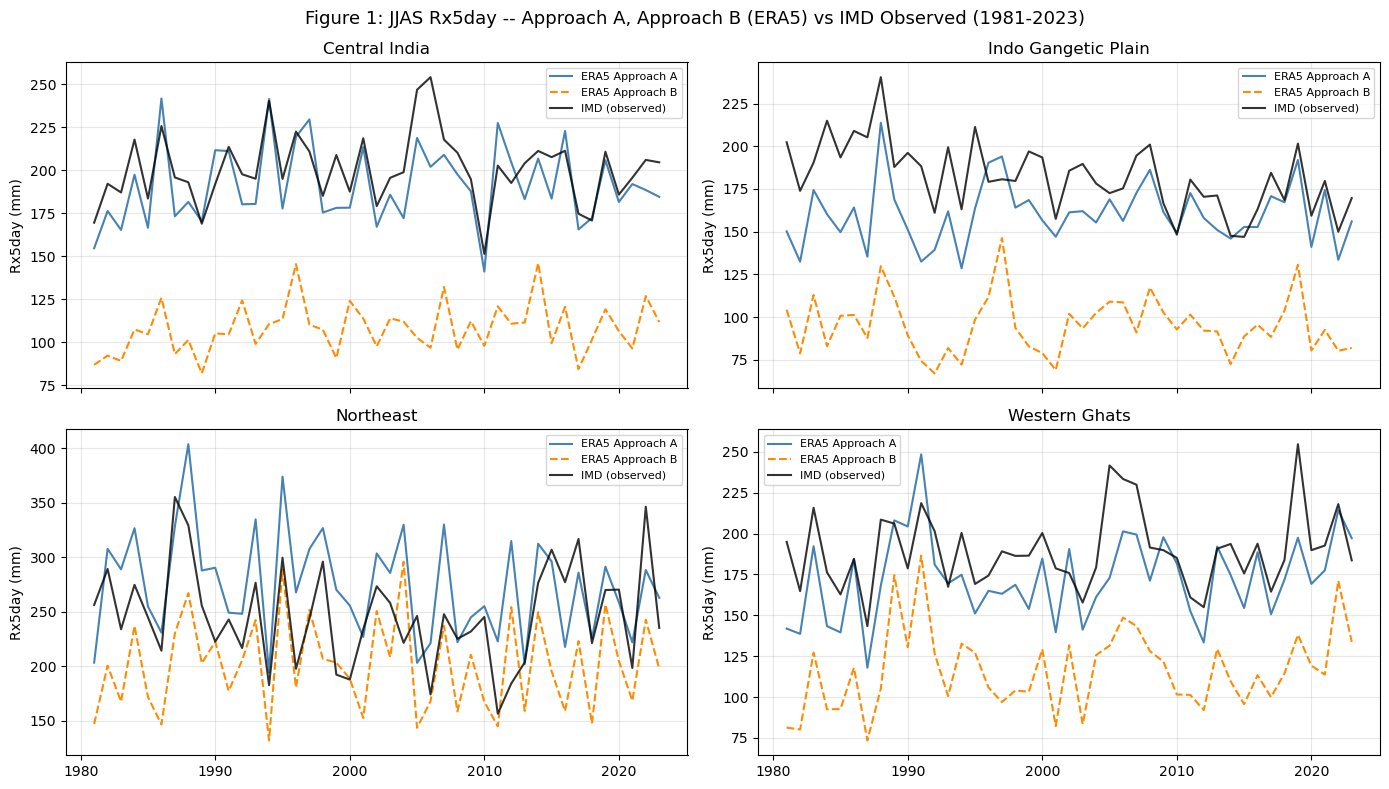

Figure 1 saved


In [20]:
import matplotlib.pyplot as plt

years = rx5day_era5_approachA.year.values

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.flatten()

for i, region in enumerate(REGION_ORDER):
    ax = axes[i]

    a_series = rx5day_era5_approachA.sel(region=region).values
    b_series = rx5day_era5_approachB.sel(region=region).values
    imd_series = rx5day_imd_approachA.sel(region=region).values

    ax.plot(years, a_series, label='ERA5 Approach A', color='steelblue')
    ax.plot(years, b_series, label='ERA5 Approach B', color='darkorange', linestyle='--')
    ax.plot(years, imd_series, label='IMD (observed)', color='black', linewidth=1.5, alpha=0.8)

    ax.set_title(region.replace('_', ' '))
    ax.set_ylabel('Rx5day (mm)')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('Figure 1: JJAS Rx5day -- Approach A, Approach B (ERA5) vs IMD Observed (1981-2023)', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + 'figure1_imd_validation_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved')

In [21]:
cwc_ext = pd.read_csv(OUTPUT_DIR + 'cwc_regional_aggregated_EXTENDED_for_correlation.csv')

combined_results = []
for region in REGION_ORDER:
    cwc_r = cwc_ext[cwc_ext.region == region].set_index('year')['regional_total_cr']
    cwc_years = cwc_r.index.values

    rain_A_cwc = rx5day_era5_approachA.sel(region=region, year=cwc_years).values
    rain_B_cwc = rx5day_era5_approachB.sel(region=region, year=cwc_years).values
    damage = cwc_r.values

    spear_A_cwc, _ = spearmanr(rain_A_cwc, damage)
    spear_B_cwc, _ = spearmanr(rain_B_cwc, damage)

    spear_A_imd = results_df.loc[results_df.region == region, 'spearman_A'].values[0]
    spear_B_imd = results_df.loc[results_df.region == region, 'spearman_B'].values[0]

    combined_results.append({
        'region': region,
        'n_cwc_years': len(cwc_years),
        'CWC_spearman_A': round(spear_A_cwc, 3),
        'CWC_spearman_B': round(spear_B_cwc, 3),
        'CWC_favours': 'A' if spear_A_cwc > spear_B_cwc else 'B',
        'IMD_spearman_A': spear_A_imd,
        'IMD_spearman_B': spear_B_imd,
        'IMD_favours': 'A' if spear_A_imd > spear_B_imd else 'B',
    })

combined_df = pd.DataFrame(combined_results)
print(combined_df.to_string(index=False))
combined_df.to_csv(OUTPUT_DIR + 'approach_ab_benchmark_comparison.csv', index=False)
print('\nSaved approach_ab_benchmark_comparison.csv')

             region  n_cwc_years  CWC_spearman_A  CWC_spearman_B CWC_favours  IMD_spearman_A  IMD_spearman_B IMD_favours
      Central_India           20           0.472           0.134           A           0.807           0.692           A
Indo_Gangetic_Plain           40           0.203          -0.134           A           0.452           0.719           B
          Northeast           40           0.089           0.183           B           0.548           0.617           B
      Western_Ghats           40           0.445           0.278           A           0.702           0.859           B

Saved approach_ab_benchmark_comparison.csv


<div style="background-color: #2E5F8A; padding: 15px; border-radius: 5px; margin-bottom: 10px;">
    <h2 style="color: white; margin: 0; font-size: 18px;">Verdict: Approach A Retained</h2>
    <p style="color: #cce0ff; margin: 5px 0 0 0; font-size: 13px;">
    Approach A (annual maximum per grid cell, then area-averaged) remains the selected method for all subsequent analysis (notebooks 05-08), on the basis of Chris's explicit decision rule: select whichever approach correlates more strongly with observed regional flood damage (CWC). Against this criterion, Approach A outperforms Approach B in 3 of 4 regions (Central_India, Indo_Gangetic_Plain, Western_Ghats), with only Northeast favouring B.
    <br><br>
    The IMD time-series benchmark (Figure 1, Part 5), computed as a supplementary check of aggregation-method fidelity to independently observed rainfall variability, shows partial agreement with this decision: it agrees with the CWC-based result in Central_India (A) and Northeast (B), but diverges in Indo_Gangetic_Plain and Western_Ghats, where IMD favours Approach B despite CWC favouring A. This divergence is concentrated in the two regions with pre-existing data-quality caveats elsewhere in this study (IGP's consistently weak explanatory power across multiple independent methods; Western_Ghats' known dilution from whole-state Maharashtra assignment), which may partly explain the sensitivity to aggregation method in these regions specifically.
    <br><br>
    <b>Note on reading Figure 1:</b> visually, IMD's observed series sits closer in absolute magnitude to Approach A in every panel — this reflects that IMD-Approach-A and ERA5-Approach-A were computed identically (per-grid Rx5day, then regional mean), so they naturally occupy a similar value range regardless of how well they track year-to-year variability. Approach B is systematically offset lower (spatial smoothing before the rolling maximum) in both datasets, making it appear visually "further" from IMD even in regions where it in fact achieves stronger rank correlation (see Part 5 table). Magnitude proximity in the plot should not be read as agreement in interannual variability; the correlation coefficients, not the visual offset, are the basis for comparison.
    <br><br>
    No changes are made to notebooks 05-08 as a result of this check. This divergence is retained as a documented limitation of the aggregation-method selection, consistent with this study's approach of reporting methodological tensions transparently rather than resolving them post hoc.
    </p>
</div>